# EDA Visual — Spotify Dataset (1921-2020)

DS5343 · Visualizacion de Datos · UTEC · Tarea 3

Este notebook complementa el reporte tabular (`eda_report.py` / `eda_report.txt`)
con los **plots exploratorios estandar** de un EDA: histogramas, boxplots, barplots,
heatmap de correlacion y series de tiempo. No incluye RadViz / Star Coordinates /
Parallel Coordinates / proyecciones — esas son las tecnicas de la **app** (Flask+D3),
no del EDA.

Todas las figuras se guardan tambien en `eda/figures/*.png` para poder embeberse en
el README.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

RAW = Path("../data/raw")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# Paleta de marca (misma usada en la app D3, ver skill dataviz / references/palette.md)
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE_SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
GRAY = "#898781"
DIVERGING = LinearSegmentedColormap.from_list("brand_diverging", ["#2a78d6", "#f0efec", "#e34948"])

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "grid.color": "#e1e0d9", "figure.facecolor": "white", "axes.facecolor": "white",
})
plt.rcParams["font.family"] = "sans-serif"


def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, dpi=150, bbox_inches="tight")
    plt.show()

## 1. Carga de datos

In [2]:
data = pd.read_csv(RAW / "data.csv")
by_year = pd.read_csv(RAW / "data_by_year.csv")
by_genres = pd.read_csv(RAW / "data_by_genres.csv")
w_genres = pd.read_csv(RAW / "data_w_genres.csv")

print(f"data.csv: {data.shape[0]:,} filas x {data.shape[1]} columnas")
data.head(3)

data.csv: 170,653 filas x 19 columnas


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


## 2. Datos faltantes y placeholders

No hay `NaN` clasicos en ninguna tabla, pero `data_w_genres.csv` codifica la
ausencia de genero como lista vacia `"[]"` (string), no como nulo. Este es el
hallazgo de "missingness" mas relevante del dataset.

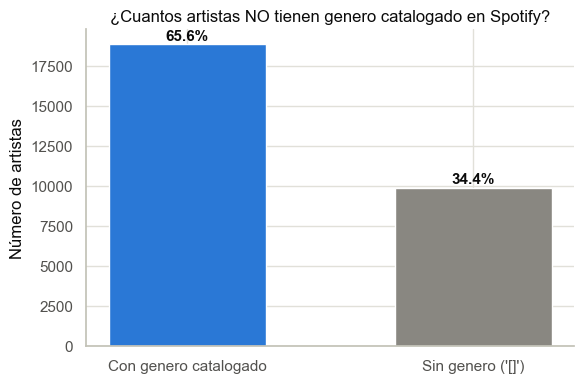

In [3]:
has_genre = (w_genres["genres"] != "[]").map({True: "Con genero catalogado", False: "Sin genero ('[]')"})
counts = has_genre.value_counts()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[CAT[0], GRAY], width=0.55)
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 300, f"{p:.1f}%",
            ha="center", fontsize=11, fontweight="bold", color="#0b0b0b")
ax.set_ylabel("N\u00famero de artistas")
ax.set_title("¿Cuantos artistas NO tienen genero catalogado en Spotify?")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig01_missing_genre.png")

## 3. Duplicados

`id` es unico (0 duplicados exactos), pero existen **duplicados logicos**: mismo
`name` + `artists` + `duration_ms` con `id` distinto — tipicamente remasters o
re-releases del mismo tema.

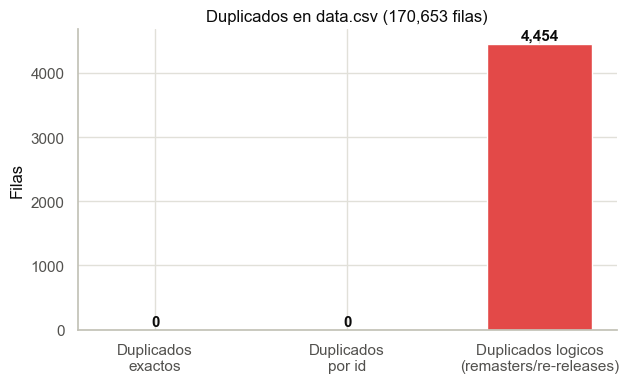

In [4]:
def parse_artists(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return [x]

exact_dup = data.duplicated().sum()
id_dup = data.duplicated(subset=["id"]).sum()
logical_dup = data.duplicated(subset=["name", "artists", "duration_ms"]).sum()

labels = ["Duplicados\nexactos", "Duplicados\npor id", "Duplicados logicos\n(remasters/re-releases)"]
values = [exact_dup, id_dup, logical_dup]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(labels, values, color=[GRAY, GRAY, CAT[5]], width=0.55)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 60, f"{v:,}",
            ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Filas")
ax.set_title("Duplicados en data.csv (170,653 filas)")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig02_duplicates.png")

## 4. Distribuciones de los rasgos de audio

Histogramas de las 9 features de audio "puras" (escala Spotify `[0,1]` salvo
`loudness` y `tempo`). Se observa el sesgo fuerte hacia 0 de `instrumentalness`,
`speechiness` y `liveness` — clave para interpretar los outliers de la seccion 5.

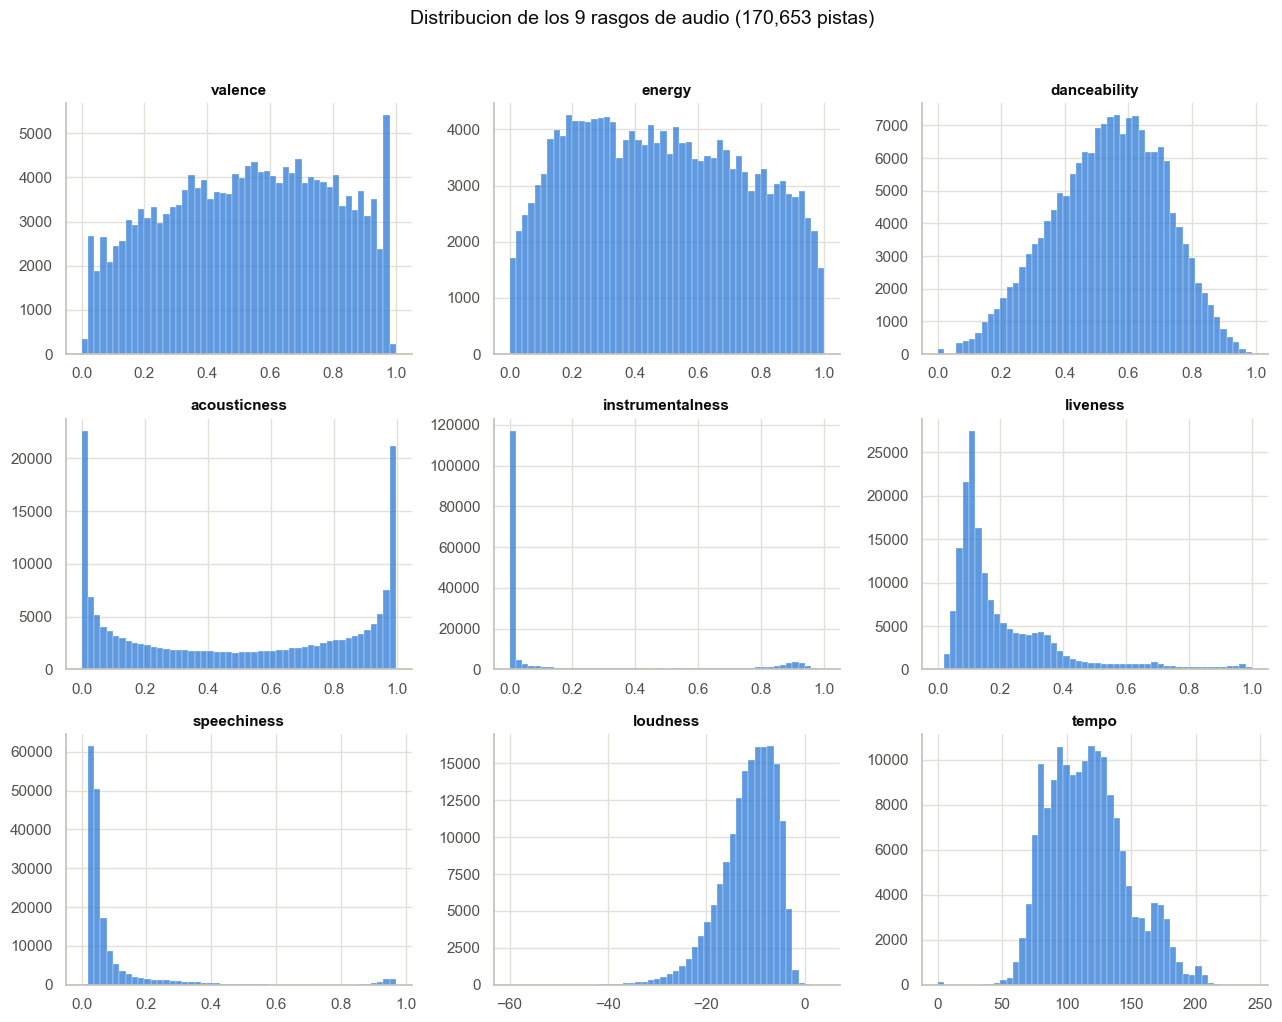

In [5]:
features = ["valence", "energy", "danceability", "acousticness", "instrumentalness",
            "liveness", "speechiness", "loudness", "tempo"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, feat in zip(axes.flat, features):
    sns.histplot(data[feat], bins=50, color=CAT[0], edgecolor="white", linewidth=0.2, ax=ax)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Distribucion de los 9 rasgos de audio (170,653 pistas)", fontsize=14, y=1.02)
savefig(fig, "fig03_histograms.png")

## 5. Outliers — boxplots

Boxplots sobre las features normalizadas `[0,1]`. Como se documenta en el reporte
tabular, el IQR marca "outlier" a un % alto de `instrumentalness`/`speechiness`
precisamente porque su distribucion es de cola larga, no porque haya errores de
captura.

C:\Users\jimen\AppData\Local\Temp\ipykernel_2984\3091747766.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[f] for f in norm_feats], labels=norm_feats, patch_artist=True,


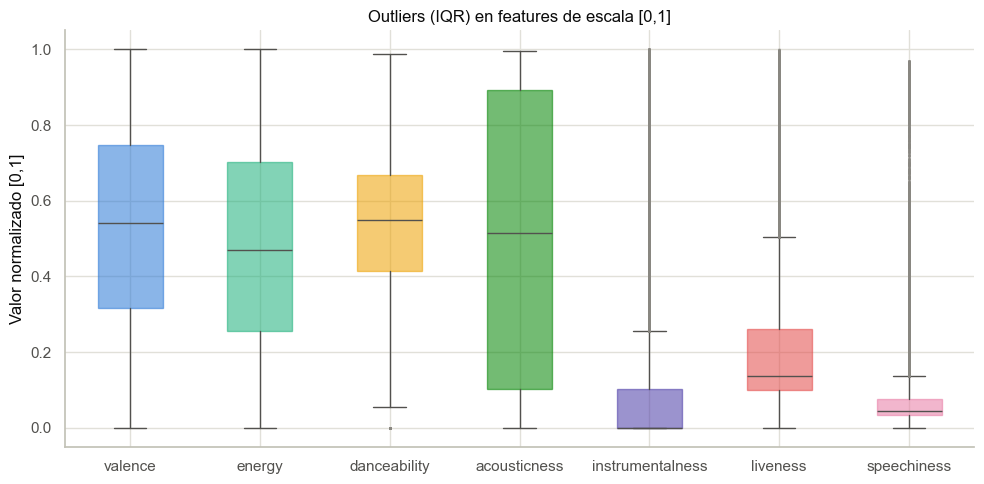

In [6]:
norm_feats = ["valence", "energy", "danceability", "acousticness",
              "instrumentalness", "liveness", "speechiness"]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([data[f] for f in norm_feats], labels=norm_feats, patch_artist=True,
                 flierprops=dict(marker="o", markersize=2, markerfacecolor=GRAY, markeredgecolor="none", alpha=0.3))
for patch, color in zip(bp["boxes"], CAT):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
    patch.set_edgecolor(color)
for element in ["whiskers", "caps", "medians"]:
    plt.setp(bp[element], color="#52514e")
ax.set_ylabel("Valor normalizado [0,1]")
ax.set_title("Outliers (IQR) en features de escala [0,1]")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig04_boxplots.png")

## 6. Por que normalizar: comparacion de escalas

`loudness`, `tempo` y `duration_ms` viven en escalas completamente distintas a las
demas features. Si no se normalizan antes de usarlas en RadViz/Star
Coordinates/Parallel Coordinates, dominan visualmente solo por su rango — no
porque sean mas relevantes.

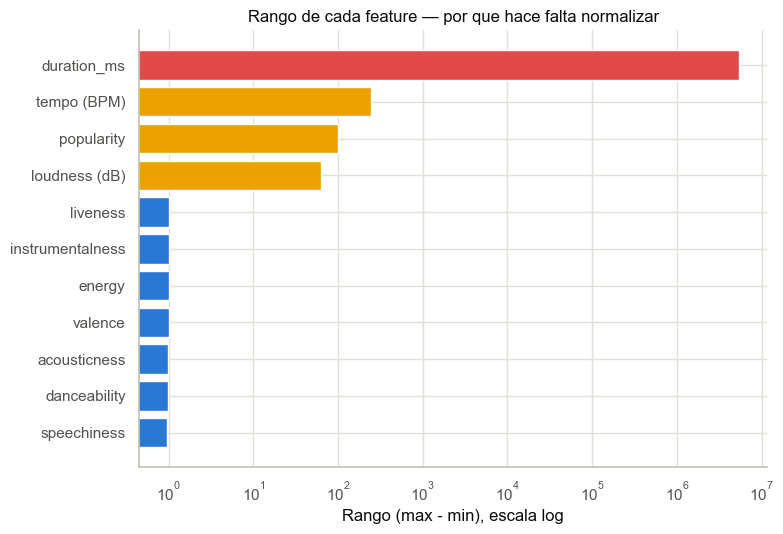

In [7]:
ranges = pd.DataFrame({
    "feature": ["valence", "acousticness", "danceability", "energy", "instrumentalness",
                "liveness", "speechiness", "loudness (dB)", "tempo (BPM)", "duration_ms",
                "popularity"],
    "min": [data[c].min() for c in ["valence", "acousticness", "danceability", "energy",
            "instrumentalness", "liveness", "speechiness", "loudness", "tempo", "duration_ms", "popularity"]],
    "max": [data[c].max() for c in ["valence", "acousticness", "danceability", "energy",
            "instrumentalness", "liveness", "speechiness", "loudness", "tempo", "duration_ms", "popularity"]],
})
ranges["range"] = ranges["max"] - ranges["min"]
ranges = ranges.sort_values("range")

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [CAT[0] if r < 10 else (CAT[2] if r < 1000 else CAT[5]) for r in ranges["range"]]
ax.barh(ranges["feature"], ranges["range"], color=colors)
ax.set_xscale("log")
ax.set_xlabel("Rango (max - min), escala log")
ax.set_title("Rango de cada feature — por que hace falta normalizar")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig05_scale_ranges.png")

## 7. Matriz de correlacion

Colormap divergente (azul-rojo, igual que la paleta de la app) centrado en 0. Los
pares mas fuertes (`energy`~`loudness`, `acousticness`~`energy`,
`popularity`~`year`) se discuten en el README.

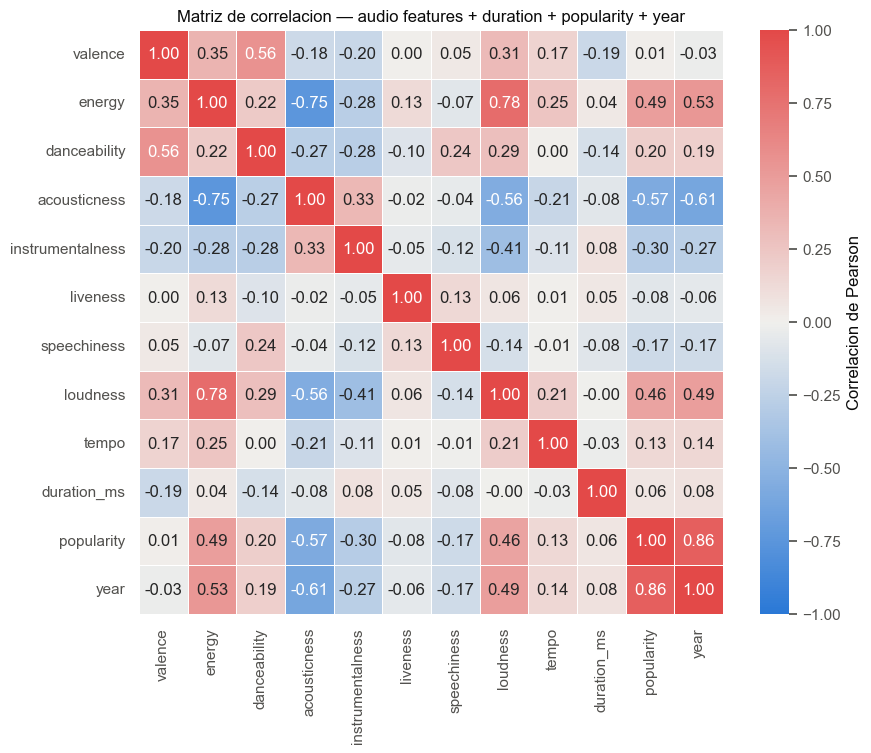

In [8]:
corr_cols = features + ["duration_ms", "popularity", "year"]
corr = data[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, cmap=DIVERGING, center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Correlacion de Pearson"}, ax=ax)
ax.set_title("Matriz de correlacion — audio features + duration + popularity + year")
savefig(fig, "fig06_correlation_heatmap.png")

## 8. Evolucion temporal por decada ("la guerra del volumen")

Small multiples (un eje Y por feature, nunca un doble eje) coloreados con la rampa
secuencial de marca. Cada panel es una serie temporal de la media por decada.

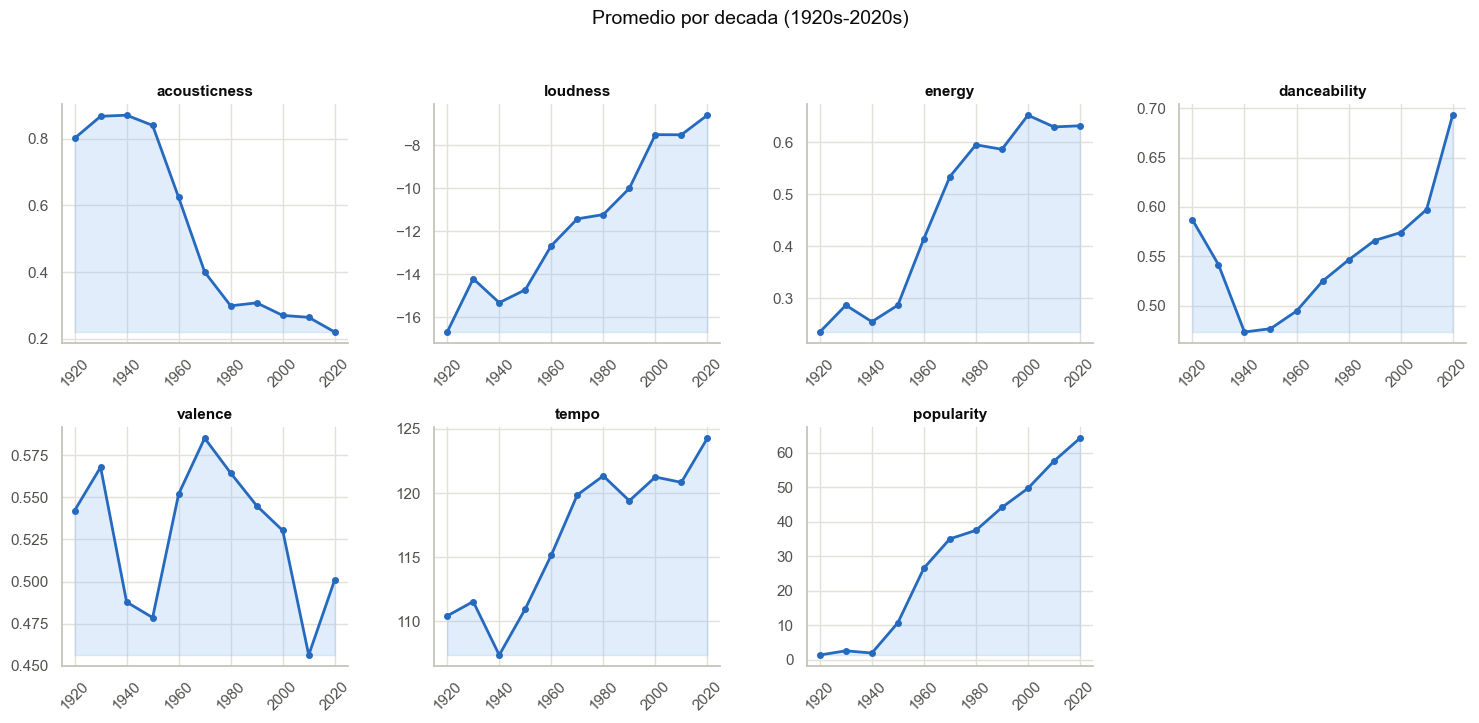

In [9]:
decade = (data["year"] // 10 * 10)
trend = data.assign(decade=decade).groupby("decade")[
    ["acousticness", "loudness", "energy", "danceability", "valence", "tempo", "popularity"]
].mean()

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
panel_feats = trend.columns.tolist()
for ax, feat in zip(axes.flat, panel_feats):
    ax.plot(trend.index, trend[feat], color=BLUE_SEQ[4], linewidth=2, marker="o", markersize=4)
    ax.fill_between(trend.index, trend[feat], trend[feat].min(), color=BLUE_SEQ[1], alpha=0.3)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=45)
axes.flat[-1].axis("off")
fig.suptitle("Promedio por decada (1920s-2020s)", fontsize=14, y=1.03)
savefig(fig, "fig07_decade_trends.png")

## 9. La paradoja de la popularidad

`popularity` (absoluta) correlaciona 0.86 con `year` — el algoritmo de Spotify
favorece estrenos recientes. A la derecha, `popularity_pct_in_year` (percentil
dentro del propio año) corrige ese sesgo.

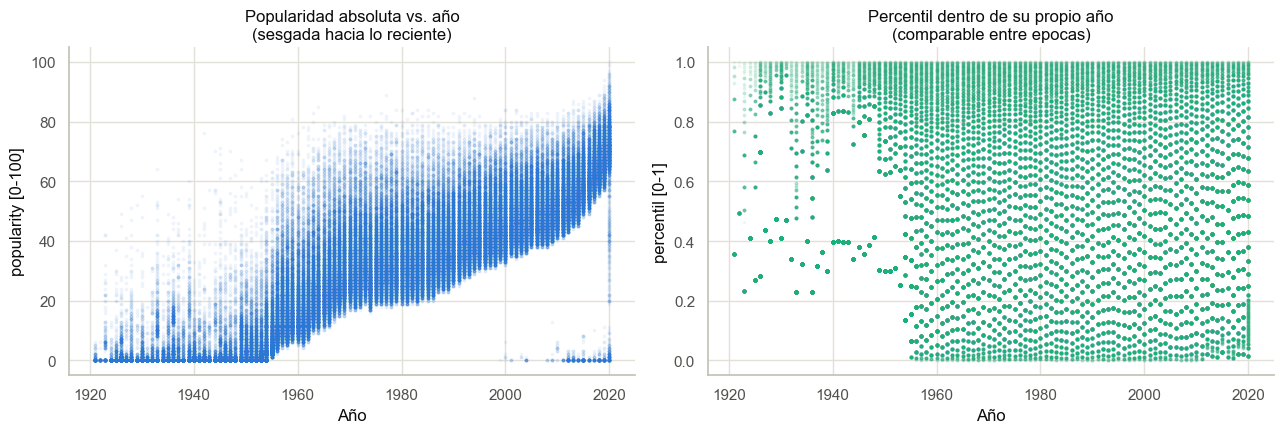

In [10]:
data["popularity_pct_in_year"] = data.groupby("year")["popularity"].rank(pct=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(data["year"], data["popularity"], s=3, alpha=0.05, color=CAT[0])
axes[0].set_title("Popularidad absoluta vs. año\n(sesgada hacia lo reciente)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("popularity [0-100]")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].scatter(data["year"], data["popularity_pct_in_year"], s=3, alpha=0.05, color=CAT[1])
axes[1].set_title("Percentil dentro de su propio año\n(comparable entre epocas)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("percentil [0-1]")
axes[1].spines[["top", "right"]].set_visible(False)
savefig(fig, "fig08_popularity_paradox.png")

## 10. Géneros más frecuentes (tras enriquecimiento)

Top 15 géneros por número de pistas, tras el join `data.csv` ↔ `data_w_genres.csv`
por artista principal.

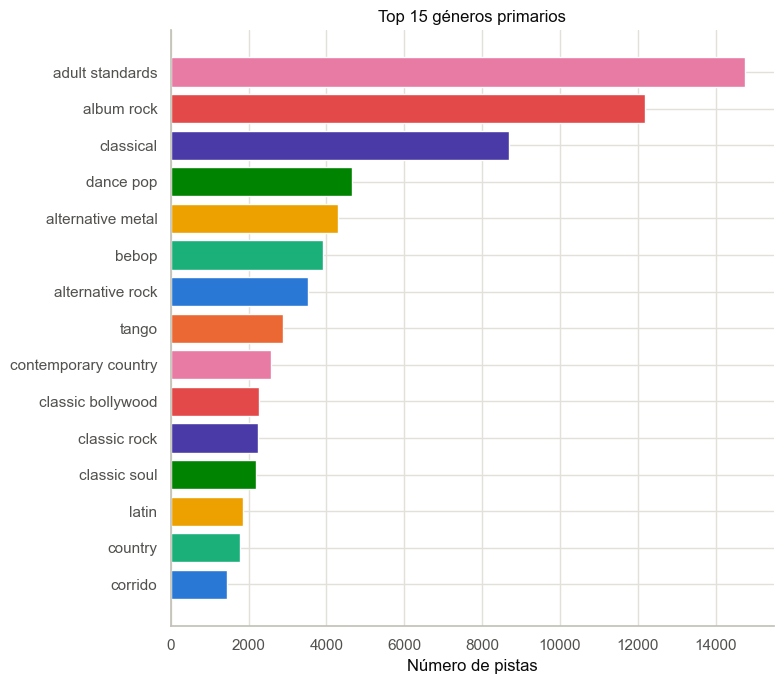

In [11]:
def safe_list(x):
    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else [x]
    except (ValueError, SyntaxError):
        return []

w_genres["primary_genre"] = w_genres["genres"].apply(lambda x: (safe_list(x) or [None])[0])
artist_to_genre = dict(zip(w_genres["artists"], w_genres["primary_genre"]))
data["main_artist"] = data["artists"].apply(lambda x: (safe_list(x) or ["Unknown"])[0])
data["primary_genre"] = data["main_artist"].map(artist_to_genre)

top15 = data["primary_genre"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
bar_colors = [CAT[i % len(CAT)] for i in range(len(top15))]
ax.barh(top15.index, top15.values, color=bar_colors)
ax.set_xlabel("Número de pistas")
ax.set_title("Top 15 géneros primarios")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig09_top_genres.png")

## 11. Colaboraciones (número de artistas por pista)

20.2% de las pistas tienen más de un artista. Eje Y en escala log por la cola
larga (hasta 40 artistas en una sola pista).

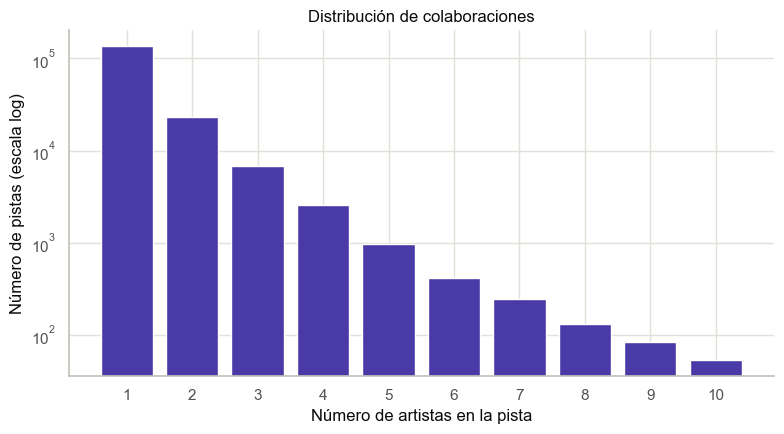

In [12]:
n_artists = data["artists"].apply(lambda x: len(safe_list(x)))
counts = n_artists.value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(counts.index.astype(str), counts.values, color=CAT[4])
ax.set_yscale("log")
ax.set_xlabel("Número de artistas en la pista")
ax.set_ylabel("Número de pistas (escala log)")
ax.set_title("Distribución de colaboraciones")
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig10_collaborations.png")

## 12. Sanity check de duración

Histograma de `duration_ms` con las líneas de corte usadas en la limpieza (5s como
umbral de corrupción; 30s / 20min solo como referencia visual, no se filtran por
ser interludios/clásica legítimos).

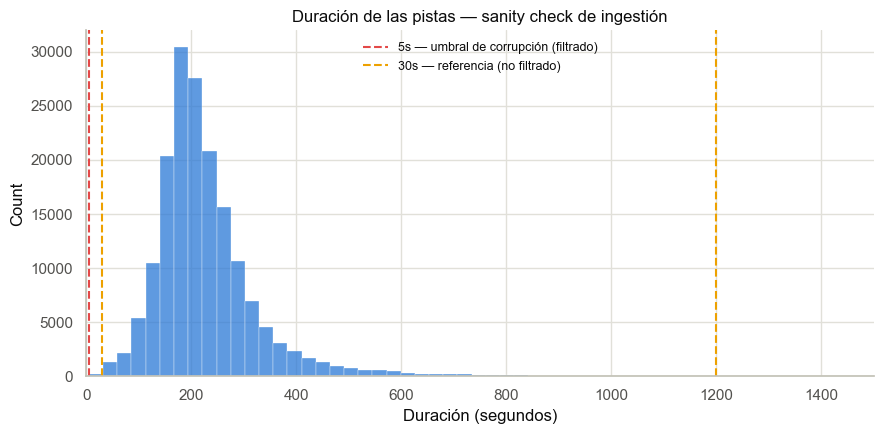

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data["duration_ms"] / 1000, bins=200, color=CAT[0], ax=ax)
ax.axvline(5, color=CAT[5], linestyle="--", linewidth=1.5, label="5s — umbral de corrupción (filtrado)")
ax.axvline(30, color=CAT[2], linestyle="--", linewidth=1.5, label="30s — referencia (no filtrado)")
ax.axvline(1200, color=CAT[2], linestyle="--", linewidth=1.5)
ax.set_xlim(0, 1500)
ax.set_xlabel("Duración (segundos)")
ax.set_title("Duración de las pistas — sanity check de ingestión")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
savefig(fig, "fig11_duration_sanity.png")

## 13. Resumen de hallazgos

1. **No hay NaN, pero 34.4% de artistas no tienen género catalogado** (`genres == "[]"`) — se deja como `"unknown"`, no se imputa.
2. **4,454 duplicados lógicos** (remasters/re-releases) — se conservan, son observaciones válidas.
3. **`loudness`, `tempo`, `duration_ms` requieren normalización** antes de usarse en RadViz/Star/Parallel — sus rangos son órdenes de magnitud distintos al resto.
4. Los "outliers" de `instrumentalness`/`speechiness`/`liveness` son la **forma natural** de distribuciones de cola larga, no errores.
5. `energy`~`loudness` (r=0.78) y `acousticness`~`energy` (r=-0.75) son los pares más colineales — relevante para no sobre-interpretar RadViz cuando ambos anclajes están activos.
6. **"Guerra del volumen"**: `loudness` sube ~10dB en un siglo; `acousticness` cae de ~0.85 a ~0.22.
7. `popularity` correlaciona 0.86 con `year` — **comparar popularidad absoluta entre épocas es engañoso**; se usa percentil dentro del año.
8. El género se enriquece por join de artista principal — **10.3% de las pistas quedan sin género** tras el join (colaboraciones, artistas sin catálogo).

Estos 8 hallazgos son la base directa de las 4 tareas analíticas de la app
(ver README, sección 4).